In [1]:
from validation_plots import create_qq_validation_plot, create_mae_data, create_amae_map_validation_plot

In [2]:
RAW_AVERAGES_PATH = "data/validation/impact_data/raw_averages"
ERROR_DATA_PATH = "data/validation/error_data"
SCENARIO = "ssp245"
GMT_FILE_PATH = "data/validation/scenario_data"
INDICATOR_DATA_PATH = "data/validation/impact_data/quantilemaps_regional"
IND_REGIONS_MAP = {"tas": ["SWE", "KHM", "PAK"], "pr": ["AUS", "QAT", "PAK"]}
successfully_calculated_errors = False

Processing tas, SWE
Got tas


[13:07:48 | rimeX | INFO] Load MAGICC ensemble data/validation/scenario_data/ssp245_MAGICC_artificial_cmip6.csv with baseline None and offset None


Processed sim data tas
Got emulations tas
Processing tas, KHM
Got tas


[13:09:01 | rimeX | INFO] Load MAGICC ensemble data/validation/scenario_data/ssp245_MAGICC_artificial_cmip6.csv with baseline None and offset None


Processed sim data tas
Got emulations tas
Processing tas, PAK
Got tas


...

Processed sim data pr
Got emulations pr
Processing pr, QAT
Got pr


[13:13:09 | rimeX | INFO] Load MAGICC ensemble data/validation/scenario_data/ssp245_MAGICC_artificial_cmip6.csv with baseline None and offset None


Processed sim data pr
Got emulations pr
Processing pr, PAK
Got pr


[13:14:24 | rimeX | INFO] Load MAGICC ensemble data/validation/scenario_data/ssp245_MAGICC_artificial_cmip6.csv with baseline None and offset None


Processed sim data pr
Got emulations pr


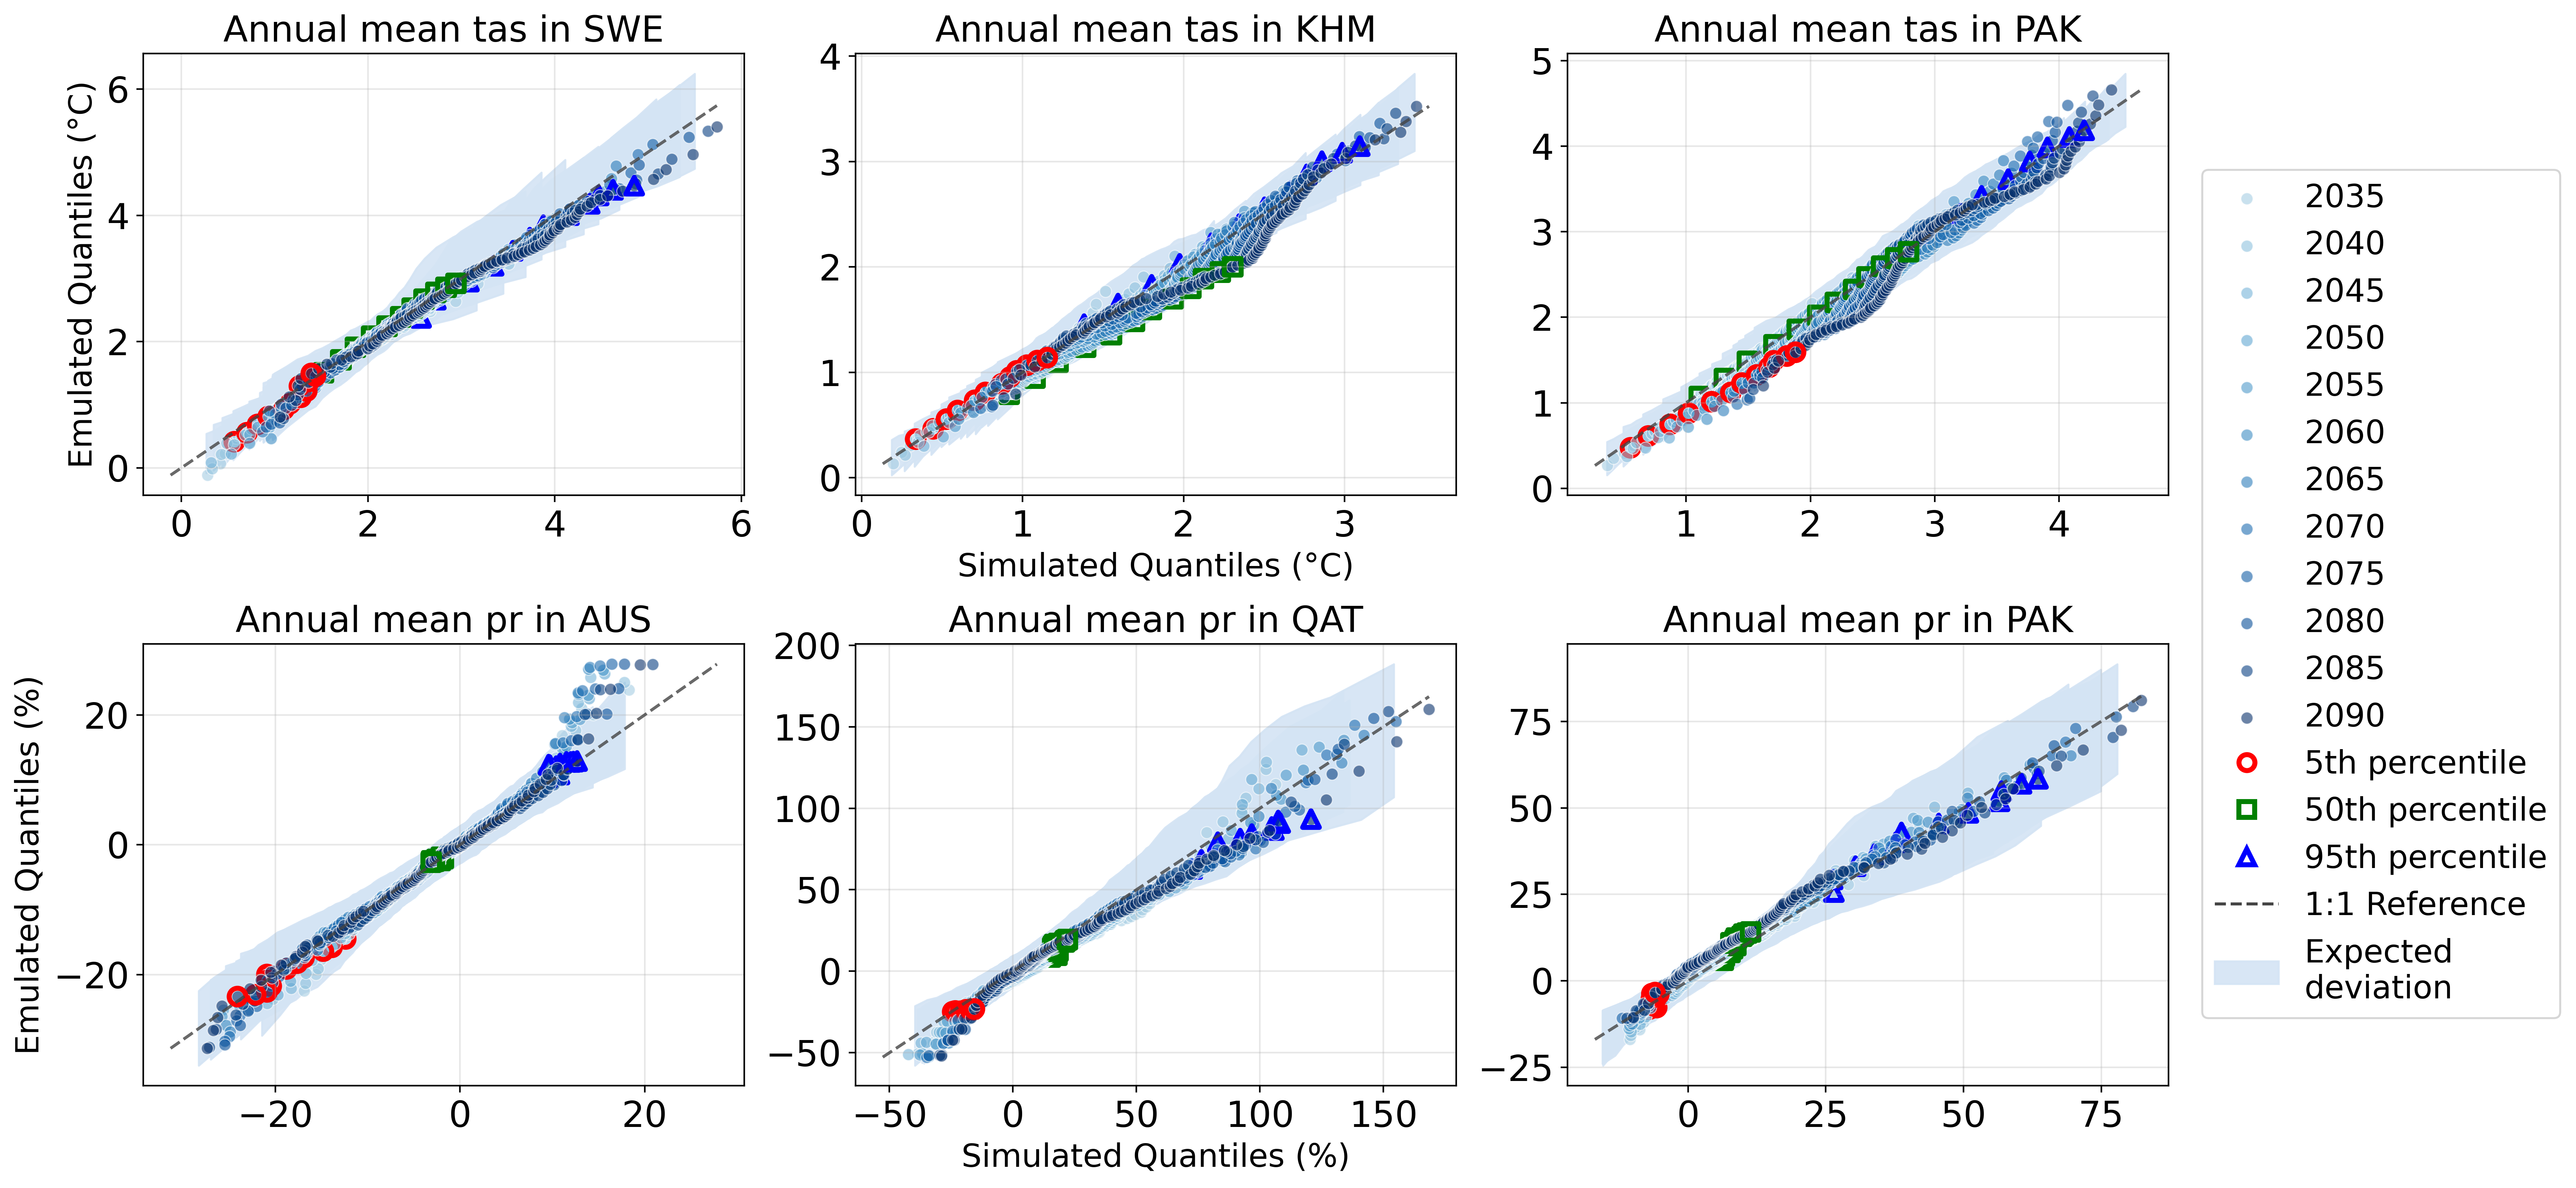

In [3]:
create_qq_validation_plot(RAW_AVERAGES_PATH, GMT_FILE_PATH, INDICATOR_DATA_PATH, SCENARIO, IND_REGIONS_MAP)

You can skip running this cell as I added the error data for the map already precalculated and it takes quite some time to run all these emulations yourself. However, if you want to calculate the errors you can use this function:

In [4]:
create_mae_data(ERROR_DATA_PATH, INDICATOR_DATA_PATH, GMT_FILE_PATH)
successfully_calculated_errors = True

IndexError: arrays used as indices must be of integer (or boolean) type

And here you can create the validation plot - if successfully_calculated_errors is True then it uses your calculation instead of the precalculated errors to obtain the map

In [ ]:
create_amae_map_validation_plot(ERROR_DATA_PATH, SCENARIO, useOwnErrorData = successfully_calculated_errors)

In [6]:
import os

for f in os.listdir(ERROR_DATA_PATH):
    print(f)

maximum_amae_tas_ssp126.json
amae_tas_ssp126.json
maximum_amae_pr_ssp245.json
amae_tas_ssp245_precalculated.json
amae_tas_ssp245.json
amae_pr_ssp245_precalculated.json
amae_pr_ssp245.json
maximum_amae_tas_ssp245.json


In [7]:
import json

with open(f"{ERROR_DATA_PATH}/amae_tas_{SCENARIO}.json") as f:
    tas = json.load(f)

print("Number of regions:", len(tas))
print(list(tas.items())[:30])

Number of regions: 30
[('IRN', 0.029790256107754015), ('LSO', 0.03159215296455674), ('SEN', 0.057494621338224645), ('AIA', 0.054361136374102136), ('DNK', 0.027581892657963864), ('FJI', 0.034011158929809486), ('LCA', 0.0568974092602217), ('VUT', 0.04926686593987421), ('TON', 0.030115565635392187), ('GTM', 0.04243872448744792), ('RWA', 0.04931311051254588), ('PRI', 0.059765937761031805), ('MAF', 0.054361136374102136), ('ZWE', 0.048414370608349834), ('MMR', 0.031084615344098575), ('LBN', 0.052953337009045934), ('LBY', 0.03544239659654345), ('ALB', 0.03738312642851584), ('VEN', 0.03529206908538868), ('THA', 0.034942884805084055), ('SAH', 0.037624103428818396), ('BLM', 0.054361136374102136), ('MSR', 0.05432326240152198), ('BLZ', 0.04702284811303642), ('MOZ', 0.05512589025796139), ('ISL', 0.03406484401490751), ('KNA', 0.05337226506915577), ('TCD', 0.05193707930486606), ('ESB', 0.05066198556623534), ('ATF', 0.049315442106377796)]


In [8]:
with open(f"{ERROR_DATA_PATH}/amae_pr_{SCENARIO}.json") as f:
    pr = json.load(f)

print("Number of regions:", len(pr))
print(list(pr.items())[:10])

Number of regions: 30
[('IRN', 0.01885045895577957), ('LSO', 0.013486189648912869), ('SEN', 0.026038085645166825), ('AIA', 0.04323328894277452), ('DNK', 0.01698126930445124), ('FJI', 0.02160467518805789), ('LCA', 0.035131793639620615), ('VUT', 0.020696489326644262), ('TON', 0.019804963607858325), ('GTM', 0.0528614882722847)]


Plot 1: Top 15 Regions with Highest Error

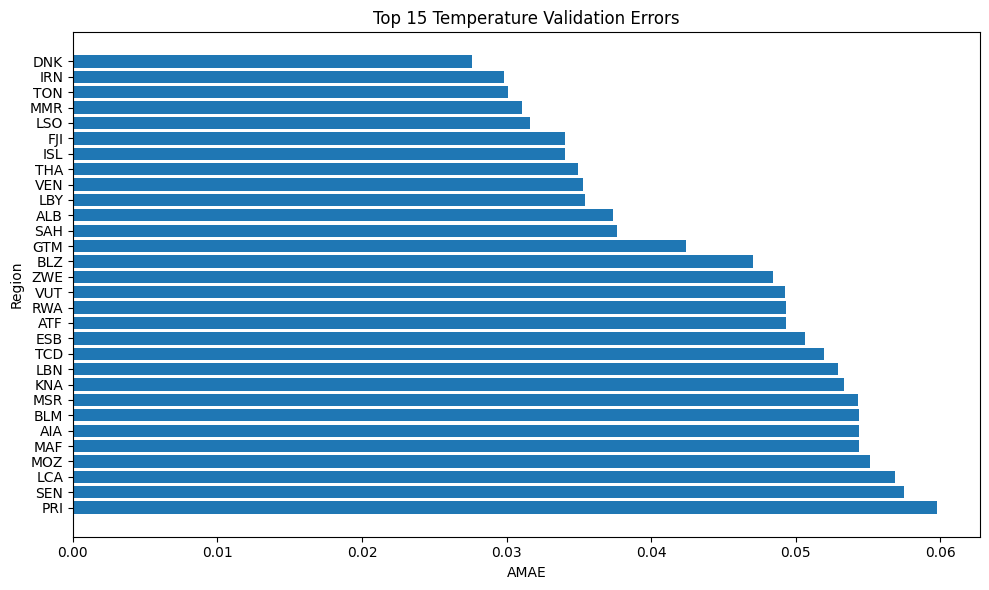

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(
    list(tas.items()),
    columns=["Region","AMAE"]
)

df = df.sort_values(
    "AMAE",
    ascending=False
).head(30)

plt.figure(figsize=(10,6))

plt.barh(
    df["Region"],
    df["AMAE"]
)

plt.xlabel("AMAE")
plt.ylabel("Region")
plt.title("Top 15 Temperature Validation Errors")

plt.tight_layout()
plt.show()

Plot 2: Error Distribution Histogram

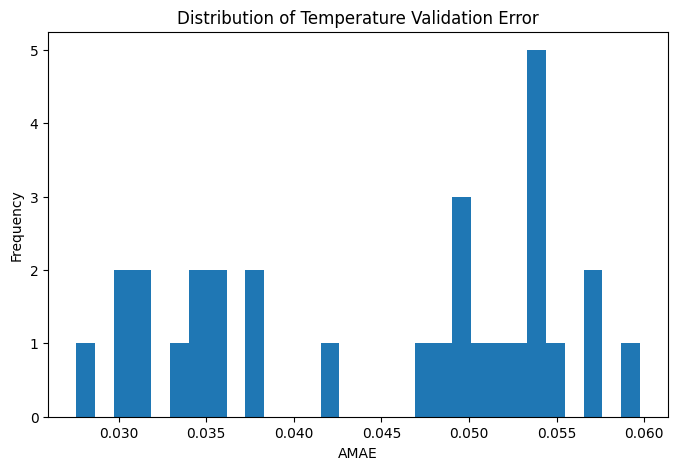

In [10]:
plt.figure(figsize=(8,5))

plt.hist(
    list(tas.values()),
    bins=30
)

plt.xlabel("AMAE")
plt.ylabel("Frequency")
plt.title("Distribution of Temperature Validation Error")

plt.show()

Plot 3: Temperature vs Precipitation Error

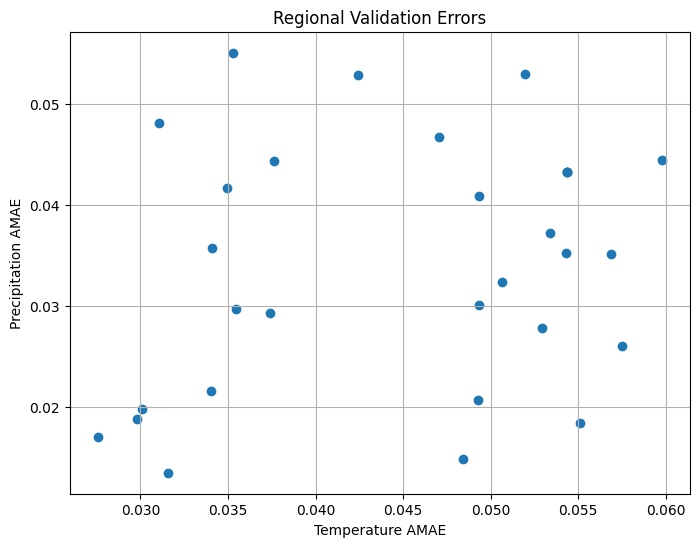

In [11]:
common_regions = sorted(
    set(tas.keys()) &
    set(pr.keys())
)

x = [tas[r] for r in common_regions]
y = [pr[r] for r in common_regions]

plt.figure(figsize=(8,6))

plt.scatter(x,y)

plt.xlabel("Temperature AMAE")
plt.ylabel("Precipitation AMAE")
plt.title("Regional Validation Errors")

plt.grid(True)

plt.show()

Plot 4: Regional Ranking

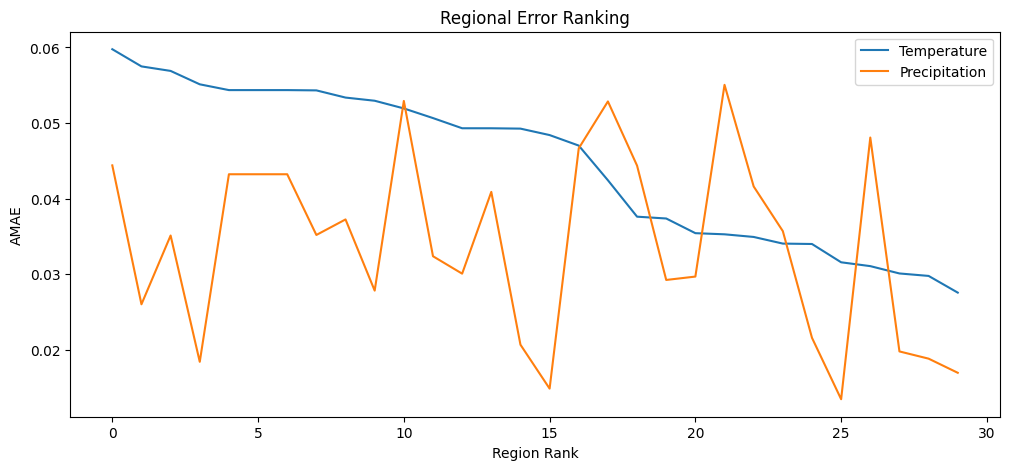

In [12]:
df = pd.DataFrame({
    "Region": common_regions,
    "Temp_Error":[tas[r] for r in common_regions],
    "Prec_Error":[pr[r] for r in common_regions]
})

df = df.sort_values(
    "Temp_Error",
    ascending=False
)

plt.figure(figsize=(12,5))

plt.plot(
    range(len(df)),
    df["Temp_Error"],
    label="Temperature"
)

plt.plot(
    range(len(df)),
    df["Prec_Error"],
    label="Precipitation"
)

plt.legend()

plt.xlabel("Region Rank")
plt.ylabel("AMAE")

plt.title("Regional Error Ranking")

plt.show()

Plot 5: Boxplot Comparison

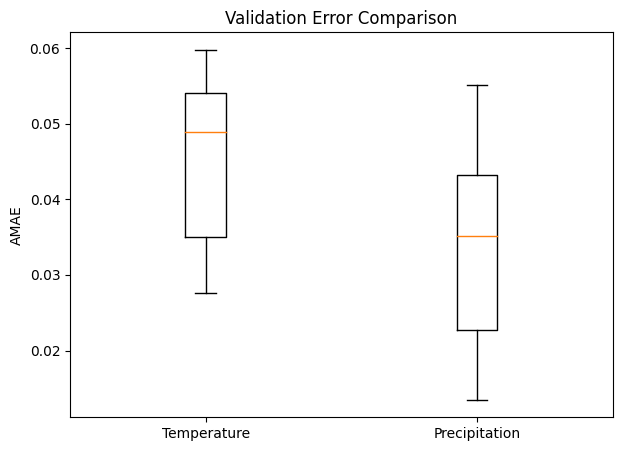

In [13]:
plt.figure(figsize=(7,5))

plt.boxplot([
    list(tas.values()),
    list(pr.values())
],
labels=["Temperature","Precipitation"])

plt.ylabel("AMAE")

plt.title("Validation Error Comparison")

plt.show()

In [14]:
import os
print(os.listdir(ERROR_DATA_PATH))

['maximum_amae_tas_ssp126.json', 'amae_tas_ssp126.json', 'maximum_amae_pr_ssp245.json', 'amae_tas_ssp245_precalculated.json', 'amae_tas_ssp245.json', 'amae_pr_ssp245_precalculated.json', 'amae_pr_ssp245.json', 'maximum_amae_tas_ssp245.json']


In [15]:
import json

with open(f"{ERROR_DATA_PATH}/amae_tas_ssp245.json") as f:
    tas = json.load(f)

with open(f"{ERROR_DATA_PATH}/amae_pr_ssp245.json") as f:
    pr = json.load(f)

print("TAS Regions:", len(tas))
print("PR Regions :", len(pr))

print("\nFirst 10 TAS entries:")
for k,v in list(tas.items())[:30]:
    print(k, v)

TAS Regions: 30
PR Regions : 30

First 10 TAS entries:
IRN 0.029790256107754015
LSO 0.03159215296455674
SEN 0.057494621338224645
AIA 0.054361136374102136
DNK 0.027581892657963864
FJI 0.034011158929809486
LCA 0.0568974092602217
VUT 0.04926686593987421
TON 0.030115565635392187
GTM 0.04243872448744792
RWA 0.04931311051254588
PRI 0.059765937761031805
MAF 0.054361136374102136
ZWE 0.048414370608349834
MMR 0.031084615344098575
LBN 0.052953337009045934
LBY 0.03544239659654345
ALB 0.03738312642851584
VEN 0.03529206908538868
THA 0.034942884805084055
SAH 0.037624103428818396
BLM 0.054361136374102136
MSR 0.05432326240152198
BLZ 0.04702284811303642
MOZ 0.05512589025796139
ISL 0.03406484401490751
KNA 0.05337226506915577
TCD 0.05193707930486606
ESB 0.05066198556623534
ATF 0.049315442106377796


Plot 1 — Regional Error Ranking (Most Useful)

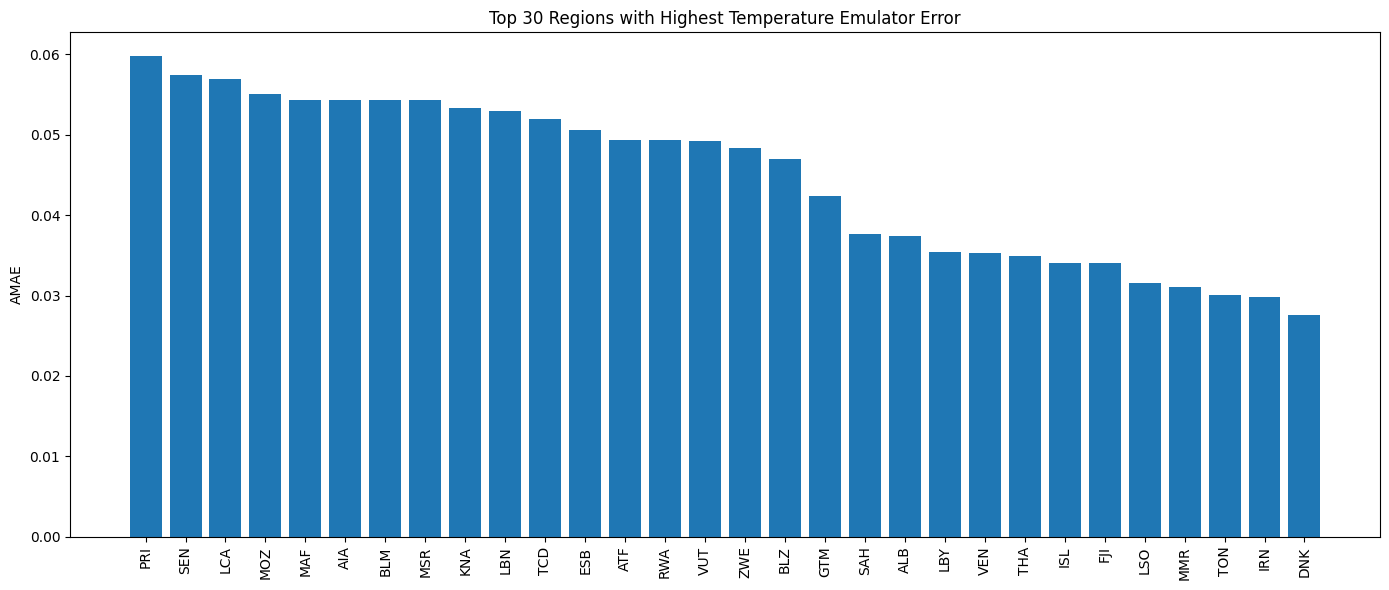

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(
    list(tas.items()),
    columns=["Region","AMAE"]
)

df = df.sort_values(
    "AMAE",
    ascending=False
)

plt.figure(figsize=(14,6))

plt.bar(
    df["Region"][:30],
    df["AMAE"][:30]
)

plt.xticks(rotation=90)

plt.ylabel("AMAE")

plt.title(
    "Top 30 Regions with Highest Temperature Emulator Error"
)

plt.tight_layout()
plt.show()

Interpretation
Large bars = regions where emulator performs poorly.
Small bars = regions where emulator reproduces impacts accurately.

This is often the first validation figure shown in emulator papers.

Plot 2 — Temperature vs Precipitation Error

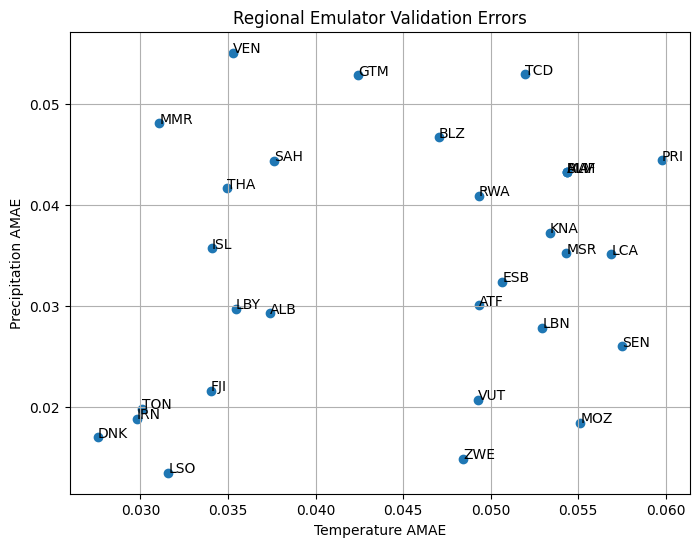

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

common = sorted(
    set(tas.keys()) &
    set(pr.keys())
)

x = [tas[r] for r in common]
y = [pr[r] for r in common]

plt.figure(figsize=(8,6))

plt.scatter(x,y)

for i,r in enumerate(common):
    if i < 30:
        plt.annotate(r,(x[i],y[i]))

plt.xlabel("Temperature AMAE")
plt.ylabel("Precipitation AMAE")

plt.title(
    "Regional Emulator Validation Errors"
)

plt.grid(True)

plt.show()

Interpretation

Upper-right regions:

difficult for both temperature and precipitation.

Lower-left:

well reproduced by RIME-X.

Plot 3 — Error Distribution

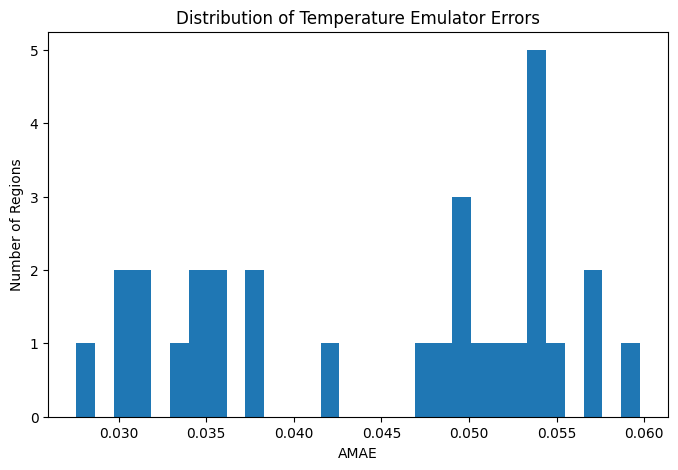

In [19]:
plt.figure(figsize=(8,5))

plt.hist(
    list(tas.values()),
    bins=30
)

plt.xlabel("AMAE")
plt.ylabel("Number of Regions")

plt.title(
    "Distribution of Temperature Emulator Errors"
)

plt.show()

Plot 4 — Compare Temperature and Precipitation

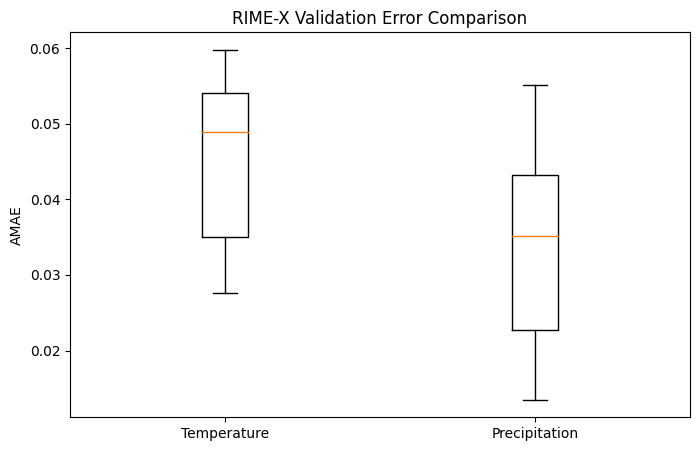

In [20]:
plt.figure(figsize=(8,5))

plt.boxplot(
    [
        list(tas.values()),
        list(pr.values())
    ],
    labels=[
        "Temperature",
        "Precipitation"
    ]
)

plt.ylabel("AMAE")

plt.title(
    "RIME-X Validation Error Comparison"
)

plt.show()

Plot 5 — Cumulative Error Distribution (Research Quality)

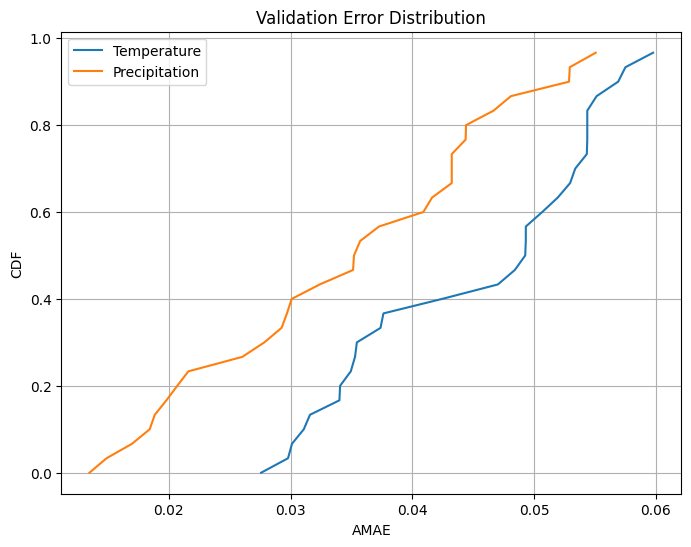

In [21]:
import numpy as np

tas_sorted = np.sort(
    list(tas.values())
)

pr_sorted = np.sort(
    list(pr.values())
)

tas_cdf = np.arange(
    len(tas_sorted)
)/len(tas_sorted)

pr_cdf = np.arange(
    len(pr_sorted)
)/len(pr_sorted)

plt.figure(figsize=(8,6))

plt.plot(
    tas_sorted,
    tas_cdf,
    label="Temperature"
)

plt.plot(
    pr_sorted,
    pr_cdf,
    label="Precipitation"
)

plt.xlabel("AMAE")
plt.ylabel("CDF")

plt.legend()

plt.title(
    "Validation Error Distribution"
)

plt.grid(True)

plt.show()

Plot 6 — Global Region Map (Closest to the Paper)

In [22]:
print(sorted(tas.keys()))

['AIA', 'ALB', 'ATF', 'BLM', 'BLZ', 'DNK', 'ESB', 'FJI', 'GTM', 'IRN', 'ISL', 'KNA', 'LBN', 'LBY', 'LCA', 'LSO', 'MAF', 'MMR', 'MOZ', 'MSR', 'PRI', 'RWA', 'SAH', 'SEN', 'TCD', 'THA', 'TON', 'VEN', 'VUT', 'ZWE']


| ISO-3 Code | Country / Territory                                                                      |
| ---------- | ---------------------------------------------------------------------------------------- |
| AIA        | Anguilla                                                                                 |
| ALB        | Albania                                                                                  |
| ATF        | French Southern Territories                                                              |
| BLM        | Saint Barthélemy                                                                         |
| BLZ        | Belize                                                                                   |
| DNK        | Denmark                                                                                  |
| ESB        | Saint Eustatius, Saba and Bonaire (Caribbean Netherlands grouping used in some datasets) |
| FJI        | Fiji                                                                                     |
| GTM        | Guatemala                                                                                |
| IRN        | Iran                                                                                     |
| ISL        | Iceland                                                                                  |
| KNA        | Saint Kitts and Nevis                                                                    |
| LBN        | Lebanon                                                                                  |
| LBY        | Libya                                                                                    |
| LCA        | Saint Lucia                                                                              |
| LSO        | Lesotho                                                                                  |
| MAF        | Saint Martin (French part)                                                               |
| MMR        | Myanmar                                                                                  |
| MOZ        | Mozambique                                                                               |
| MSR        | Montserrat                                                                               |
| PRI        | Puerto Rico                                                                              |
| RWA        | Rwanda                                                                                   |
| SAH        | Western Sahara                                                                           |
| SEN        | Senegal                                                                                  |
| TCD        | Chad                                                                                     |
| THA        | Thailand                                                                                 |
| TON        | Tonga                                                                                    |
| VEN        | Venezuela                                                                                |
| VUT        | Vanuatu                                                                                  |
| ZWE        | Zimbabwe                                                                                 |


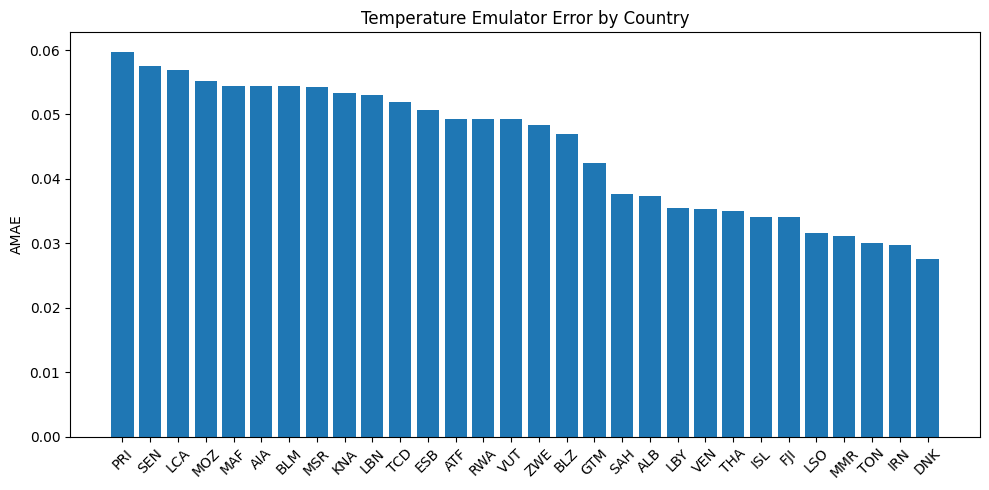

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(
    list(tas.items()),
    columns=["Country","AMAE"]
)

df = df.sort_values(
    "AMAE",
    ascending=False
)

plt.figure(figsize=(10,5))

plt.bar(
    df["Country"],
    df["AMAE"]
)

plt.xticks(rotation=45)

plt.ylabel("AMAE")
plt.title("Temperature Emulator Error by Country")

plt.tight_layout()
plt.show()

In [24]:
print("TAS regions =", len(tas))
print("PR regions =", len(pr))

print(tas)

TAS regions = 30
PR regions = 30
{'IRN': 0.029790256107754015, 'LSO': 0.03159215296455674, 'SEN': 0.057494621338224645, 'AIA': 0.054361136374102136, 'DNK': 0.027581892657963864, 'FJI': 0.034011158929809486, 'LCA': 0.0568974092602217, 'VUT': 0.04926686593987421, 'TON': 0.030115565635392187, 'GTM': 0.04243872448744792, 'RWA': 0.04931311051254588, 'PRI': 0.059765937761031805, 'MAF': 0.054361136374102136, 'ZWE': 0.048414370608349834, 'MMR': 0.031084615344098575, 'LBN': 0.052953337009045934, 'LBY': 0.03544239659654345, 'ALB': 0.03738312642851584, 'VEN': 0.03529206908538868, 'THA': 0.034942884805084055, 'SAH': 0.037624103428818396, 'BLM': 0.054361136374102136, 'MSR': 0.05432326240152198, 'BLZ': 0.04702284811303642, 'MOZ': 0.05512589025796139, 'ISL': 0.03406484401490751, 'KNA': 0.05337226506915577, 'TCD': 0.05193707930486606, 'ESB': 0.05066198556623534, 'ATF': 0.049315442106377796}


In [25]:
print(IND_REGIONS_MAP)

{'tas': ['SWE', 'KHM', 'PAK'], 'pr': ['AUS', 'QAT', 'PAK']}


In [26]:
import os

for f in [
    "amae_tas_ssp245.json",
    "amae_pr_ssp245.json"
]:
    path = f"{ERROR_DATA_PATH}/{f}"

    print(
        f,
        os.path.getsize(path)/1024,
        "KB"
    )

amae_tas_ssp245.json 0.953125 KB
amae_pr_ssp245.json 0.947265625 KB


Ranked ANMEA Plots

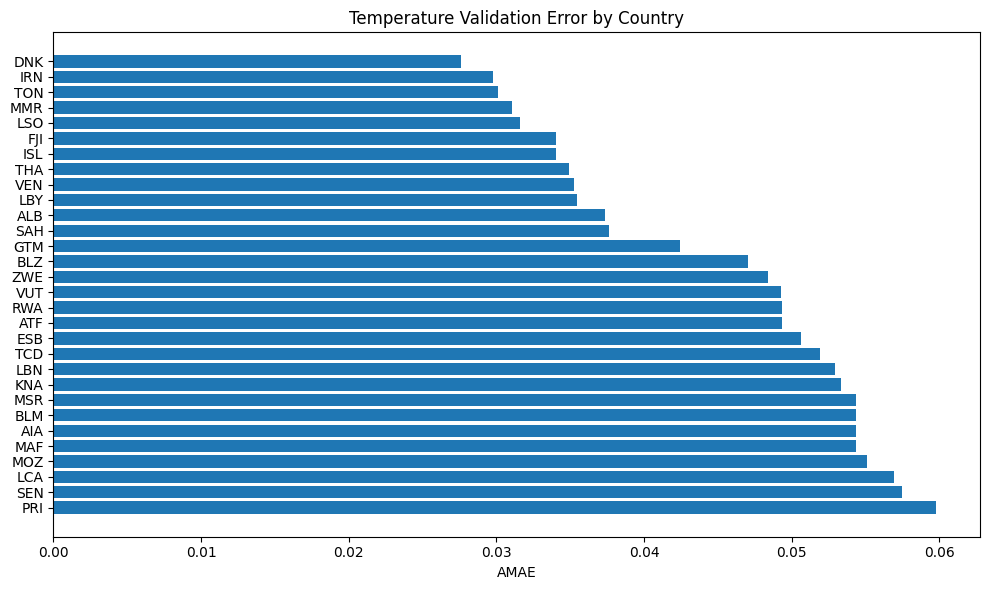

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(
    list(tas.items()),
    columns=["Country","AMAE"]
)

df = df.sort_values(
    "AMAE",
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    df["Country"],
    df["AMAE"]
)

plt.xlabel("AMAE")
plt.title(
    "Temperature Validation Error by Country"
)

plt.tight_layout()
plt.show()

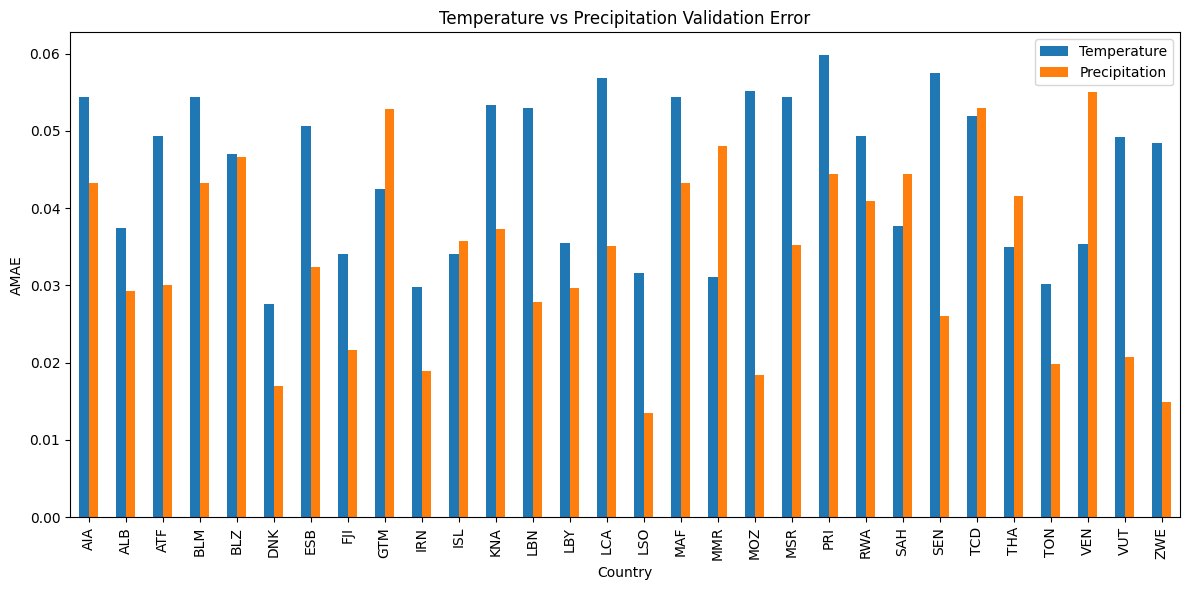

In [28]:
import pandas as pd

common = sorted(
    set(tas.keys()) &
    set(pr.keys())
)

df = pd.DataFrame({
    "Country": common,
    "Temperature":[tas[c] for c in common],
    "Precipitation":[pr[c] for c in common]
})

df.plot(
    x="Country",
    y=["Temperature","Precipitation"],
    kind="bar",
    figsize=(12,6)
)

plt.ylabel("AMAE")
plt.title(
    "Temperature vs Precipitation Validation Error"
)

plt.tight_layout()
plt.show()